# EduLink  — Model 2: Job Demand Forecasting
**Industry-Level | PySpark + statsmodels | Multiple ARIMA Orders | Train/Test Split | MAE, RMSE, MAPE**

**Pipeline:**
1. Load vacancy data & assign roles
2. Build monthly time series per role
3. Train/test split (last 3 months = test)
4. Compare ARIMA orders: (1,1,1), (2,1,2), (1,1,0), (0,1,1)
5. Select best order per role by AIC
6. Evaluate: MAE, RMSE, MAPE on held-out test set
7. Forecast next 6 months
8. Visualize + save results

In [1]:
# ─── CELL 1: Setup ───
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q pyspark statsmodels
print("Setup complete.")


Mounted at /content/drive
Setup complete.


In [2]:
# ─── CELL 2: Spark Session ───
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("EDUCLINE-JobDemand-v2")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 4.0.2


In [3]:
# ─── CELL 3: Paths ───
import os

ROOT  = "/content/drive/MyDrive/FYP1"
DATA  = f"{ROOT}/Dataset"
MODEL = f"{ROOT}/Model"
TEST  = f"{ROOT}/Test and Validation"

VACANCY_PATH = f"{DATA}/synthetic_vacancies_sl_it_18mo.csv"
OUT_FORECAST = f"{DATA}/job_demand_forecast.csv"
OUT_METRICS  = f"{TEST}/job_demand_model_metrics.csv"

for folder_path in [DATA, MODEL, TEST]:
    os.makedirs(folder_path, exist_ok=True)

print("Vacancy folder exists:", os.path.exists(VACANCY_PATH), "->", VACANCY_PATH)


Vacancy folder exists: True -> /content/drive/MyDrive/FYP1/Dataset/synthetic_vacancies_sl_it_18mo.csv


In [4]:
# ─── CELL 4: Load & Normalize Job Titles to Roles ───
vacX = (spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(VACANCY_PATH))   # single CSV file

print(f"Rows: {vacX.count()} | Columns: {vacX.columns}")

title = F.lower(F.col("job_title"))

vacX = vacX.withColumn("role",
    F.when(title.rlike("data scientist|machine learning|ml engineer|ai engineer"), "ML/AI Engineer")
     .when(title.rlike("data engineer|etl"),                                       "Data Engineer")
     .when(title.rlike("data analyst|business intelligence|bi "),                  "Data Analyst")
     .when(title.rlike("devops|site reliability|sre"),                             "DevOps/SRE")
     .when(title.rlike("cloud|aws|azure|gcp"),                                     "Cloud Engineer")
     .when(title.rlike("cyber|security|soc|infosec"),                              "Cybersecurity")
     .when(title.rlike("network|systems engineer|infrastructure"),                 "Network/Systems")
     .when(title.rlike("qa|quality assurance|test engineer|tester"),               "QA Engineer")
     .when(title.rlike("ui|ux|product designer|graphic designer"),                 "UI/UX Designer")
     .when(title.rlike("mobile|android|ios|flutter|react native"),                 "Mobile Developer")
     .when(title.rlike("frontend|front-end|react|angular|vue"),                    "Frontend Developer")
     .when(title.rlike("backend|back-end|api developer|spring|dotnet|node"),       "Backend Developer")
     .when(title.rlike("full stack|full-stack"),                                   "Full Stack Developer")
     .when(title.rlike("software engineer|software developer|developer|programmer"),"Software Engineer")
     .when(title.rlike("business analyst|ba "),                                    "Business Analyst")
     .when(title.rlike("project manager|scrum master|product manager"),            "PM/PO/Scrum")
     .when(title.rlike("intern|trainee|associate"),                                "Intern/Trainee")
     .otherwise("Other"))

print("Role distribution:")
vacX.groupBy("role").count().orderBy(F.desc("count")).show(20, truncate=False)


Rows: 300 | Columns: ['vacancy_id', 'company', 'location', 'job_title', 'role_tag', 'description', 'skills', 'date_posted', 'url', 'source']
Role distribution:
+-----------------+-----+
|role             |count|
+-----------------+-----+
|Other            |60   |
|Cybersecurity    |57   |
|Software Engineer|46   |
|Network/Systems  |35   |
|PM/PO/Scrum      |27   |
|Intern/Trainee   |26   |
|QA Engineer      |16   |
|ML/AI Engineer   |16   |
|Data Engineer    |10   |
|Business Analyst |7    |
+-----------------+-----+



In [5]:
# ─── CELL 5: Build Monthly Demand Series ───
from pyspark.sql.window import Window

demand = (vacX
    .withColumn("month", F.date_format(F.to_date("date_posted"), "yyyy-MM"))
    .groupBy("role", "month")
    .agg(F.count("*").alias("job_count"))
    .orderBy("role", "month"))

mm = demand.select(F.min("month").alias("mn"), F.max("month").alias("mx")).collect()[0]
min_m, max_m = mm["mn"], mm["mx"]
print(f"Month range: {min_m} → {max_m}")

months_grid = (spark.range(1)
    .select(F.explode(
        F.sequence(F.to_date(F.lit(min_m + "-01")),
                   F.to_date(F.lit(max_m + "-01")),
                   F.expr("interval 1 month"))).alias("md"))
    .withColumn("month", F.date_format("md", "yyyy-MM"))
    .drop("md"))

roles_grid = demand.select("role").distinct()
full_grid  = roles_grid.crossJoin(months_grid)

demand_full = (full_grid
    .join(demand, ["role", "month"], "left")
    .fillna({"job_count": 0})
    .orderBy("role", "month"))

demand_full.groupBy("role").count().orderBy("count").show()


Month range: 2024-09 → 2026-02
+-----------------+-----+
|             role|count|
+-----------------+-----+
|    Cybersecurity|   18|
|   Intern/Trainee|   18|
|            Other|   18|
|  Network/Systems|   18|
| Business Analyst|   18|
|      PM/PO/Scrum|   18|
|      QA Engineer|   18|
|   ML/AI Engineer|   18|
|Software Engineer|   18|
|    Data Engineer|   18|
+-----------------+-----+



In [6]:
# ─── CELL 6: ARIMA Model Selection + Train/Test Evaluation ───
import numpy as np
import warnings
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

FORECAST_H  = 6
TEST_MONTHS = 3
MIN_POINTS  = 12

ARIMA_ORDERS = [(1,1,1), (2,1,2), (1,1,0), (0,1,1), (2,1,1)]

def add_months(y, m, k):
    yy  = y + (m - 1 + k) // 12
    mm_ = (m - 1 + k) % 12 + 1
    return yy, mm_

def eval_arima(y_train, y_test, order):
    try:
        fit   = ARIMA(y_train, order=order).fit()
        fc    = np.clip(fit.forecast(steps=len(y_test)), 0, None)
        y_arr = np.array(y_test)
        mae   = float(np.mean(np.abs(fc - y_arr)))
        rmse  = float(np.sqrt(np.mean((fc - y_arr)**2)))
        mape  = float(np.mean(np.abs((y_arr - fc) / (y_arr + 1e-9))) * 100)
        return {"aic": float(fit.aic), "mae": mae, "rmse": rmse, "mape": mape,
                "fit": fit, "order": order}
    except:
        return None

role_list = [r["role"] for r in demand_full.select("role").distinct().collect()
             if r["role"] != "Other"]

forecast_results = []
metrics_rows     = []

for role in role_list:
    rows = (demand_full.filter(F.col("role") == role)
            .orderBy("month").select("month","job_count").collect())

    if len(rows) < MIN_POINTS:
        print(f"  SKIP {role}: only {len(rows)} months")
        continue

    months_str = [r["month"] for r in rows]
    y_all      = [float(r["job_count"]) for r in rows]
    y_train    = y_all[:-TEST_MONTHS]
    y_test     = y_all[-TEST_MONTHS:]

    best_result = None
    for order in ARIMA_ORDERS:
        res = eval_arima(y_train, y_test, order)
        if res:
            if best_result is None or res["aic"] < best_result["aic"]:
                best_result = res
            metrics_rows.append({
                "role":     role,
                "order":    str(order),
                "aic":      float(round(res["aic"],  2)),
                "mae":      float(round(res["mae"],  2)),
                "rmse":     float(round(res["rmse"], 2)),
                "mape_pct": float(round(res["mape"], 2)),
            })

    if best_result is None:
        print(f"  FAIL {role}: all orders failed")
        continue

    try:
        fit_full = ARIMA(y_all, order=best_result["order"]).fit()
        fc       = np.clip(fit_full.forecast(steps=FORECAST_H), 0, None)
        last_y, last_m = map(int, months_str[-1].split("-"))
        f_months = []
        for i in range(1, FORECAST_H + 1):
            yy, mm_ = add_months(last_y, last_m, i)
            f_months.append(f"{yy:04d}-{mm_:02d}")

        avg_fc   = float(np.mean(fc))
        last_val = y_all[-1]
        trend    = ("Increasing" if avg_fc > last_val * 1.10
                    else "Decreasing" if avg_fc < last_val * 0.90
                    else "Stable")

        for mstr, pred in zip(f_months, fc):
            forecast_results.append((
                role, mstr, float(pred), trend,
                str(best_result["order"]),
                float(round(best_result["mae"],  2)),
                float(round(best_result["rmse"], 2)),
                float(round(best_result["mape"], 2)),
            ))
    except Exception as e:
        print(f"  ERROR full-refit {role}: {e}")

print(f"Forecasting done. Roles processed: {len(set(r[0] for r in forecast_results))}")

Forecasting done. Roles processed: 9


In [7]:
# ─── CELL 7: Model Metrics Summary (PySpark) ───
from pyspark.sql import functions as F

metrics_spark = spark.createDataFrame(metrics_rows)
print("=== ARIMA Order Comparison (sorted by AIC per role) ===")
metrics_spark.orderBy("role","aic").show(100, truncate=False)

print("\n=== Average MAE & RMSE per ARIMA order (across all roles) ===")
metrics_spark.groupBy("order").agg(
    F.round(F.avg("mae"),      2).alias("avg_mae"),
    F.round(F.avg("rmse"),     2).alias("avg_rmse"),
    F.round(F.avg("mape_pct"), 2).alias("avg_mape_pct"),
    F.count("*").alias("role_count")
).orderBy("avg_rmse").show(truncate=False)


=== ARIMA Order Comparison (sorted by AIC per role) ===
+-----+----+------------------+---------+----+-----------------+
|aic  |mae |mape_pct          |order    |rmse|role             |
+-----+----+------------------+---------+----+-----------------+
|26.91|0.53|3.862261191294E10 |(0, 1, 1)|0.53|Business Analyst |
|28.77|0.55|4.057244062007E10 |(1, 1, 1)|0.56|Business Analyst |
|29.9 |0.47|4.097669722095E10 |(2, 1, 2)|0.52|Business Analyst |
|30.26|0.63|4.479419456333E10 |(1, 1, 0)|0.64|Business Analyst |
|30.3 |0.48|4.18407944982E10  |(2, 1, 1)|0.53|Business Analyst |
|54.52|0.6 |27.04             |(0, 1, 1)|0.76|Cybersecurity    |
|56.48|0.62|27.73             |(1, 1, 1)|0.77|Cybersecurity    |
|57.03|0.44|16.2              |(1, 1, 0)|0.47|Cybersecurity    |
|58.97|0.45|16.15             |(2, 1, 2)|0.63|Cybersecurity    |
|58.98|0.42|18.37             |(2, 1, 1)|0.5 |Cybersecurity    |
|38.13|0.49|1.777797348602E10 |(0, 1, 1)|0.49|Data Engineer    |
|39.76|0.56|2.781357045853E10 |(1,

In [8]:
# ─── CELL 8: Save Forecast to Spark + CSV ───
import glob, shutil, os

forecast_spark = spark.createDataFrame(
    forecast_results,
    ["role", "forecast_month", "predicted_job_count", "trend",
     "best_arima_order", "test_mae", "test_rmse", "test_mape_pct"]
)

forecast_spark.orderBy("role", "forecast_month").show(30, truncate=False)

# Save forecast CSV
OUT_DIR = OUT_FORECAST.replace(".csv", "_dir")
os.makedirs(OUT_DIR, exist_ok=True)
forecast_spark.coalesce(1).write.mode("overwrite").option("header", True).csv(OUT_DIR)

parts = glob.glob(OUT_DIR + "/part-*.csv")
if parts:
    shutil.copy(parts[0], OUT_FORECAST)
    print("Saved:", OUT_FORECAST)

# Save metrics CSV — create from metrics_rows first
metrics_spark = spark.createDataFrame(metrics_rows)
OUT_METRICS_DIR = OUT_METRICS.replace(".csv", "_dir")
os.makedirs(OUT_METRICS_DIR, exist_ok=True)
metrics_spark.coalesce(1).write.mode("overwrite").option("header", True).csv(OUT_METRICS_DIR)

parts2 = glob.glob(OUT_METRICS_DIR + "/part-*.csv")
if parts2:
    shutil.copy(parts2[0], OUT_METRICS)
    print("Metrics saved:", OUT_METRICS)

+----------------+--------------+--------------------+----------+----------------+--------+---------+------------------+
|role            |forecast_month|predicted_job_count |trend     |best_arima_order|test_mae|test_rmse|test_mape_pct     |
+----------------+--------------+--------------------+----------+----------------+--------+---------+------------------+
|Business Analyst|2026-03       |0.418030082301123   |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|Business Analyst|2026-04       |0.418030082301123   |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|Business Analyst|2026-05       |0.418030082301123   |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|Business Analyst|2026-06       |0.418030082301123   |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|Business Analyst|2026-07       |0.418030082301123   |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|Business Analyst|2026-08       

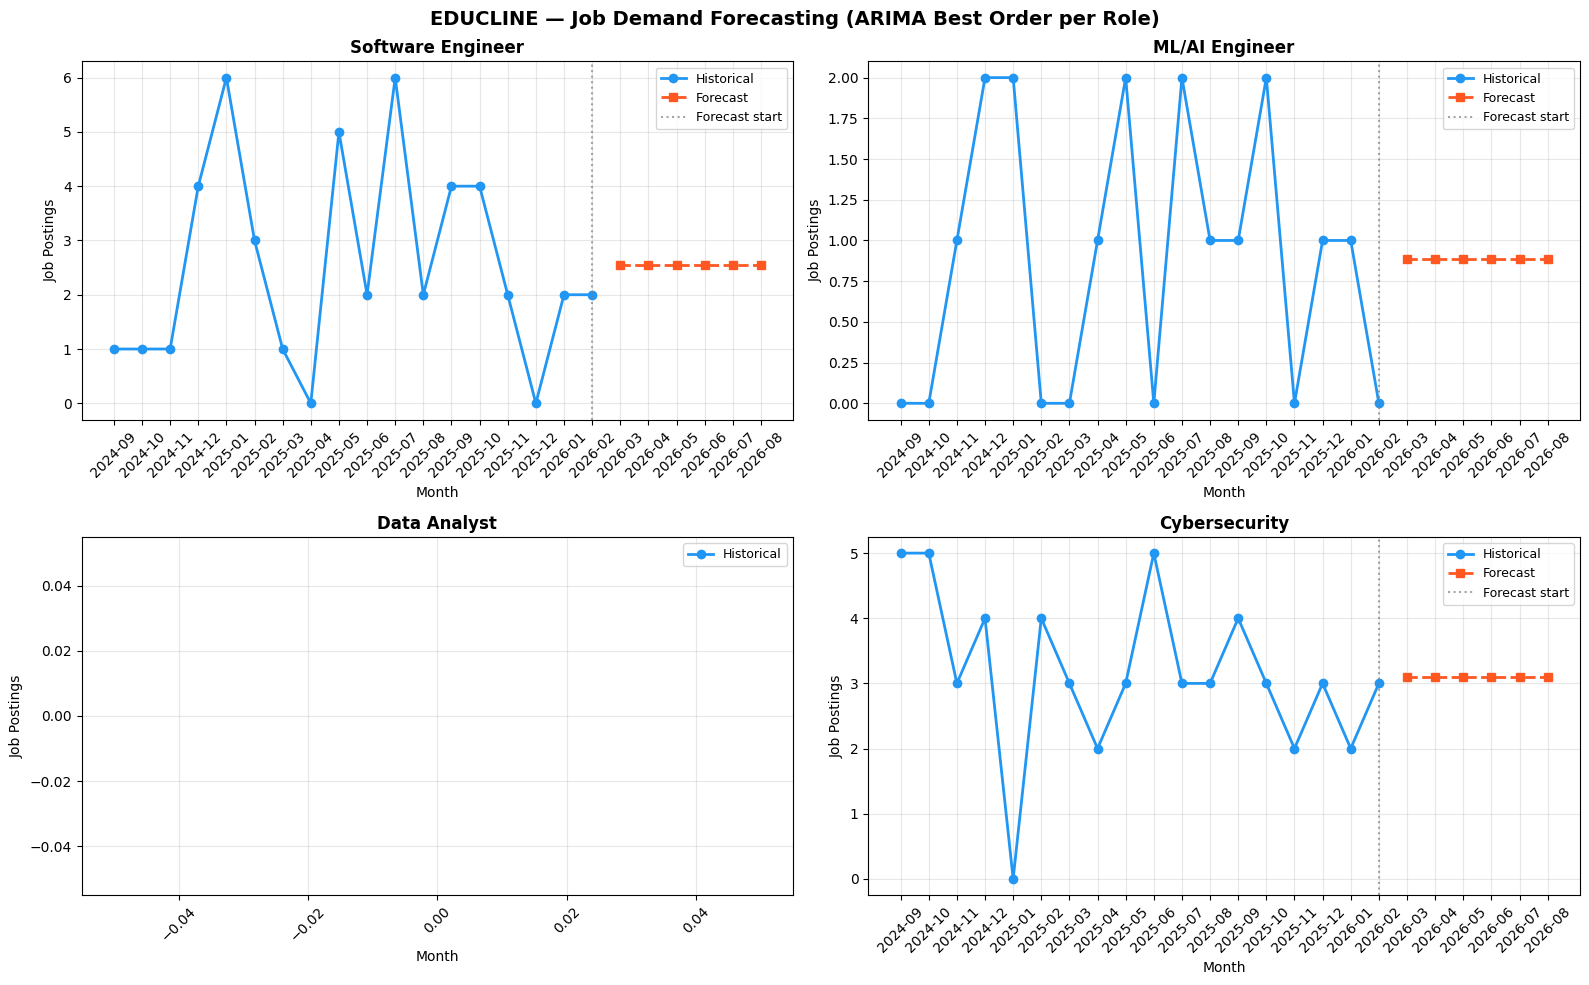

In [9]:
# ─── CELL 9: Visualization — Actual vs Forecast per Role ───
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ROLES_TO_PLOT = ["Software Engineer", "ML/AI Engineer", "Data Analyst", "Cybersecurity"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, ROLE in enumerate(ROLES_TO_PLOT):
    ax = axes[idx]
    rows = (demand_full.filter(F.col("role") == ROLE)
            .orderBy("month").select("month", "job_count").collect())
    a_months = [r["month"] for r in rows]
    a_vals   = [float(r["job_count"]) for r in rows]

    f_rows = [r for r in forecast_results if r[0] == ROLE]
    f_months = [r[1] for r in f_rows]
    f_vals   = [r[2] for r in f_rows]

    ax.plot(a_months, a_vals, marker="o", linewidth=2, label="Historical", color="#2196F3")
    if f_months:
        ax.plot(f_months, f_vals, marker="s", linestyle="--", linewidth=2, label="Forecast", color="#FF5722")
        ax.axvline(x=a_months[-1], color="gray", linestyle=":", alpha=0.7, label="Forecast start")

    ax.set_title(f"{ROLE}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Job Postings")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("EDUCLINE — Job Demand Forecasting (ARIMA Best Order per Role)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [10]:
# ─── CELL 10: Trend Summary Table (PySpark) ───
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Keep one row per role (first forecast row)
summary = (forecast_spark
    .withColumn("rn", F.row_number().over(
        Window.partitionBy("role").orderBy("forecast_month")))
    .filter(F.col("rn") == 1)
    .select("role","trend","best_arima_order","test_mae","test_rmse","test_mape_pct")
    .orderBy("test_rmse"))

print("=== Final Trend & Best ARIMA Model Summary ===")
summary.show(30, truncate=False)


=== Final Trend & Best ARIMA Model Summary ===
+-----------------+----------+----------------+--------+---------+------------------+
|role             |trend     |best_arima_order|test_mae|test_rmse|test_mape_pct     |
+-----------------+----------+----------------+--------+---------+------------------+
|Data Engineer    |Decreasing|(0, 1, 1)       |0.49    |0.49     |1.777797348602E10 |
|Business Analyst |Increasing|(0, 1, 1)       |0.53    |0.53     |3.862261191294E10 |
|ML/AI Engineer   |Increasing|(0, 1, 1)       |0.36    |0.54     |3.111113194127E10 |
|Cybersecurity    |Stable    |(0, 1, 1)       |0.6     |0.76     |27.04             |
|QA Engineer      |Increasing|(2, 1, 1)       |1.05    |1.29     |72.16             |
|PM/PO/Scrum      |Increasing|(0, 1, 1)       |1.59    |1.59     |1.587614276183E11 |
|Software Engineer|Increasing|(0, 1, 1)       |1.47    |1.74     |9.333348965234E10 |
|Intern/Trainee   |Increasing|(2, 1, 1)       |1.78    |1.99     |1.7760277341922E11|
|Networ